# MaalstroomicFlow — combined behavior and tuning diagnostics

Per-animal MaalstroomicFlow workspace: drives the behavior (lick scatter, trial outcomes) and tuning (sorted / classified heatmaps, place-cell peak-location distribution before vs after reward shift) plot helpers from a single selection. Edit the selection cell in section 2 to switch dataset, animal, session range, before/after groups, or trial type — every downstream cell consumes the resolved selection without further edits.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running plot cells picks up helper changes without reloading.

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import cmocean

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    LickContext,
    TrialOutcomeContext,
    aggregate_lick_events,
    aggregate_trial_outcomes,
    load_cue_textures,
    plot_classified_heatmap,
    plot_lick_scatter,
    plot_place_cell_peak_distribution_per_session,
    plot_place_cell_peak_distribution_around_shift,
    plot_place_cell_peak_distribution_across_animals,
    plot_post_shift_reward_zone_cells_in_session,
    plot_pre_shift_reward_zone_cells_in_session,
    plot_sorted_heatmap,
    plot_trial_outcomes,
)

## 2. Selection

Cross-cell knobs: every cell below reads these. `DATASET_PATH` is the dataset root, `ANIMAL` is a single animal id, `DISPLAY_SESSIONS` is a tuple of 1-indexed chronological session numbers shared by every per-session plot below (`None` renders every session in the animal's list), `TRIAL_TYPE` selects which trial type the tuning helpers evaluate (set to `None` to fall back to the first trial type in each helper's own resolution path), `BEFORE_SHIFT_SESSIONS` / `AFTER_SHIFT_SESSIONS` pick the two groups averaged together for the place-cell peak-location plots in sections 5.3, 5.6, and 5.7, and `FIGURE_PRESET` selects the global font-size convention (`"print"` for paper-ready sizes, `"presentation"` for the slide-projector floor). Cell-local knobs (cue textures and the lick-scatter cap / origin in section 4.1, and the cross-animal cohort in section 5.5) live with the cells that consume them.

In [25]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMAL: str = "11"
DISPLAY_SESSIONS: tuple[int, ...] | None = (15,16,18,20)
TRIAL_TYPE: str | None = None
# 1-indexed session numbers averaged together for the peak-distribution figure (5 days before
# the reward shift and 5 days after). Adjust to match this animal's actual shift day.
BEFORE_SHIFT_SESSIONS: tuple[int, ...] = (11, 12, 13, 14, 15)
AFTER_SHIFT_SESSIONS: tuple[int, ...] = (16, 17, 18, 19, 20)
# Style preset shared by every figure below. ``"print"`` matches the historical sizes used in
# the analysis package (suptitle 12 / xlabel 9 / ylabel 9 / tick 9 / legend 9, annotations 8);
# ``"presentation"`` bumps everything to the slide-projector floor (suptitle 18 / xlabel 16 /
# ylabel 16 / tick 14 / legend 14, annotations 12) so figures stay legible from the back of
# a typical conference room.
FIGURE_PRESET: str = "presentation"

## 3. Load

Reads the dataset, builds the chronologically sorted `sessions` tuple for the selected animal, and assembles the per-animal behavior contexts (`lick_context`, `outcome_context`) consumed by section 4. Tuning helpers in section 5 read `sessions`, `DISPLAY_SESSIONS`, `BEFORE_SHIFT_SESSIONS`, `AFTER_SHIFT_SESSIONS`, and `trial_type` directly.

In [26]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
sessions = tuple(
    sorted(
        dataset.get_sessions_for_animal(animal=ANIMAL),
        key=lambda dataset_session: dataset_session.session,
    )
)
if not sessions:
    raise RuntimeError(f"animal {ANIMAL!r} has no sessions in dataset {dataset.name!r}")

lick_context: LickContext = aggregate_lick_events(sessions=sessions)
outcome_context: TrialOutcomeContext = aggregate_trial_outcomes(sessions=sessions)
trial_type: str | None = TRIAL_TYPE

## 4. Behavior outputs

Per-animal behavior plots restricted to `DISPLAY_SESSIONS`. Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Lick scatter

Discrete rising-edge lick events scattered in (within-trial position, cumulative trial index) coordinates, with per-trial reward-zone rectangles drawn from each block's resolved geometry. Trial-type and geometry shifts (longitudinal mid-recording reward-zone shifts or intra-session multi-trial-type recordings) appear as different per-trial rectangles with the same color coding (rewarded vs non-rewarded relative to the trial's own reward zone).

Uses `DISPLAY_SESSIONS` from the selection cell to pick which sessions to render.

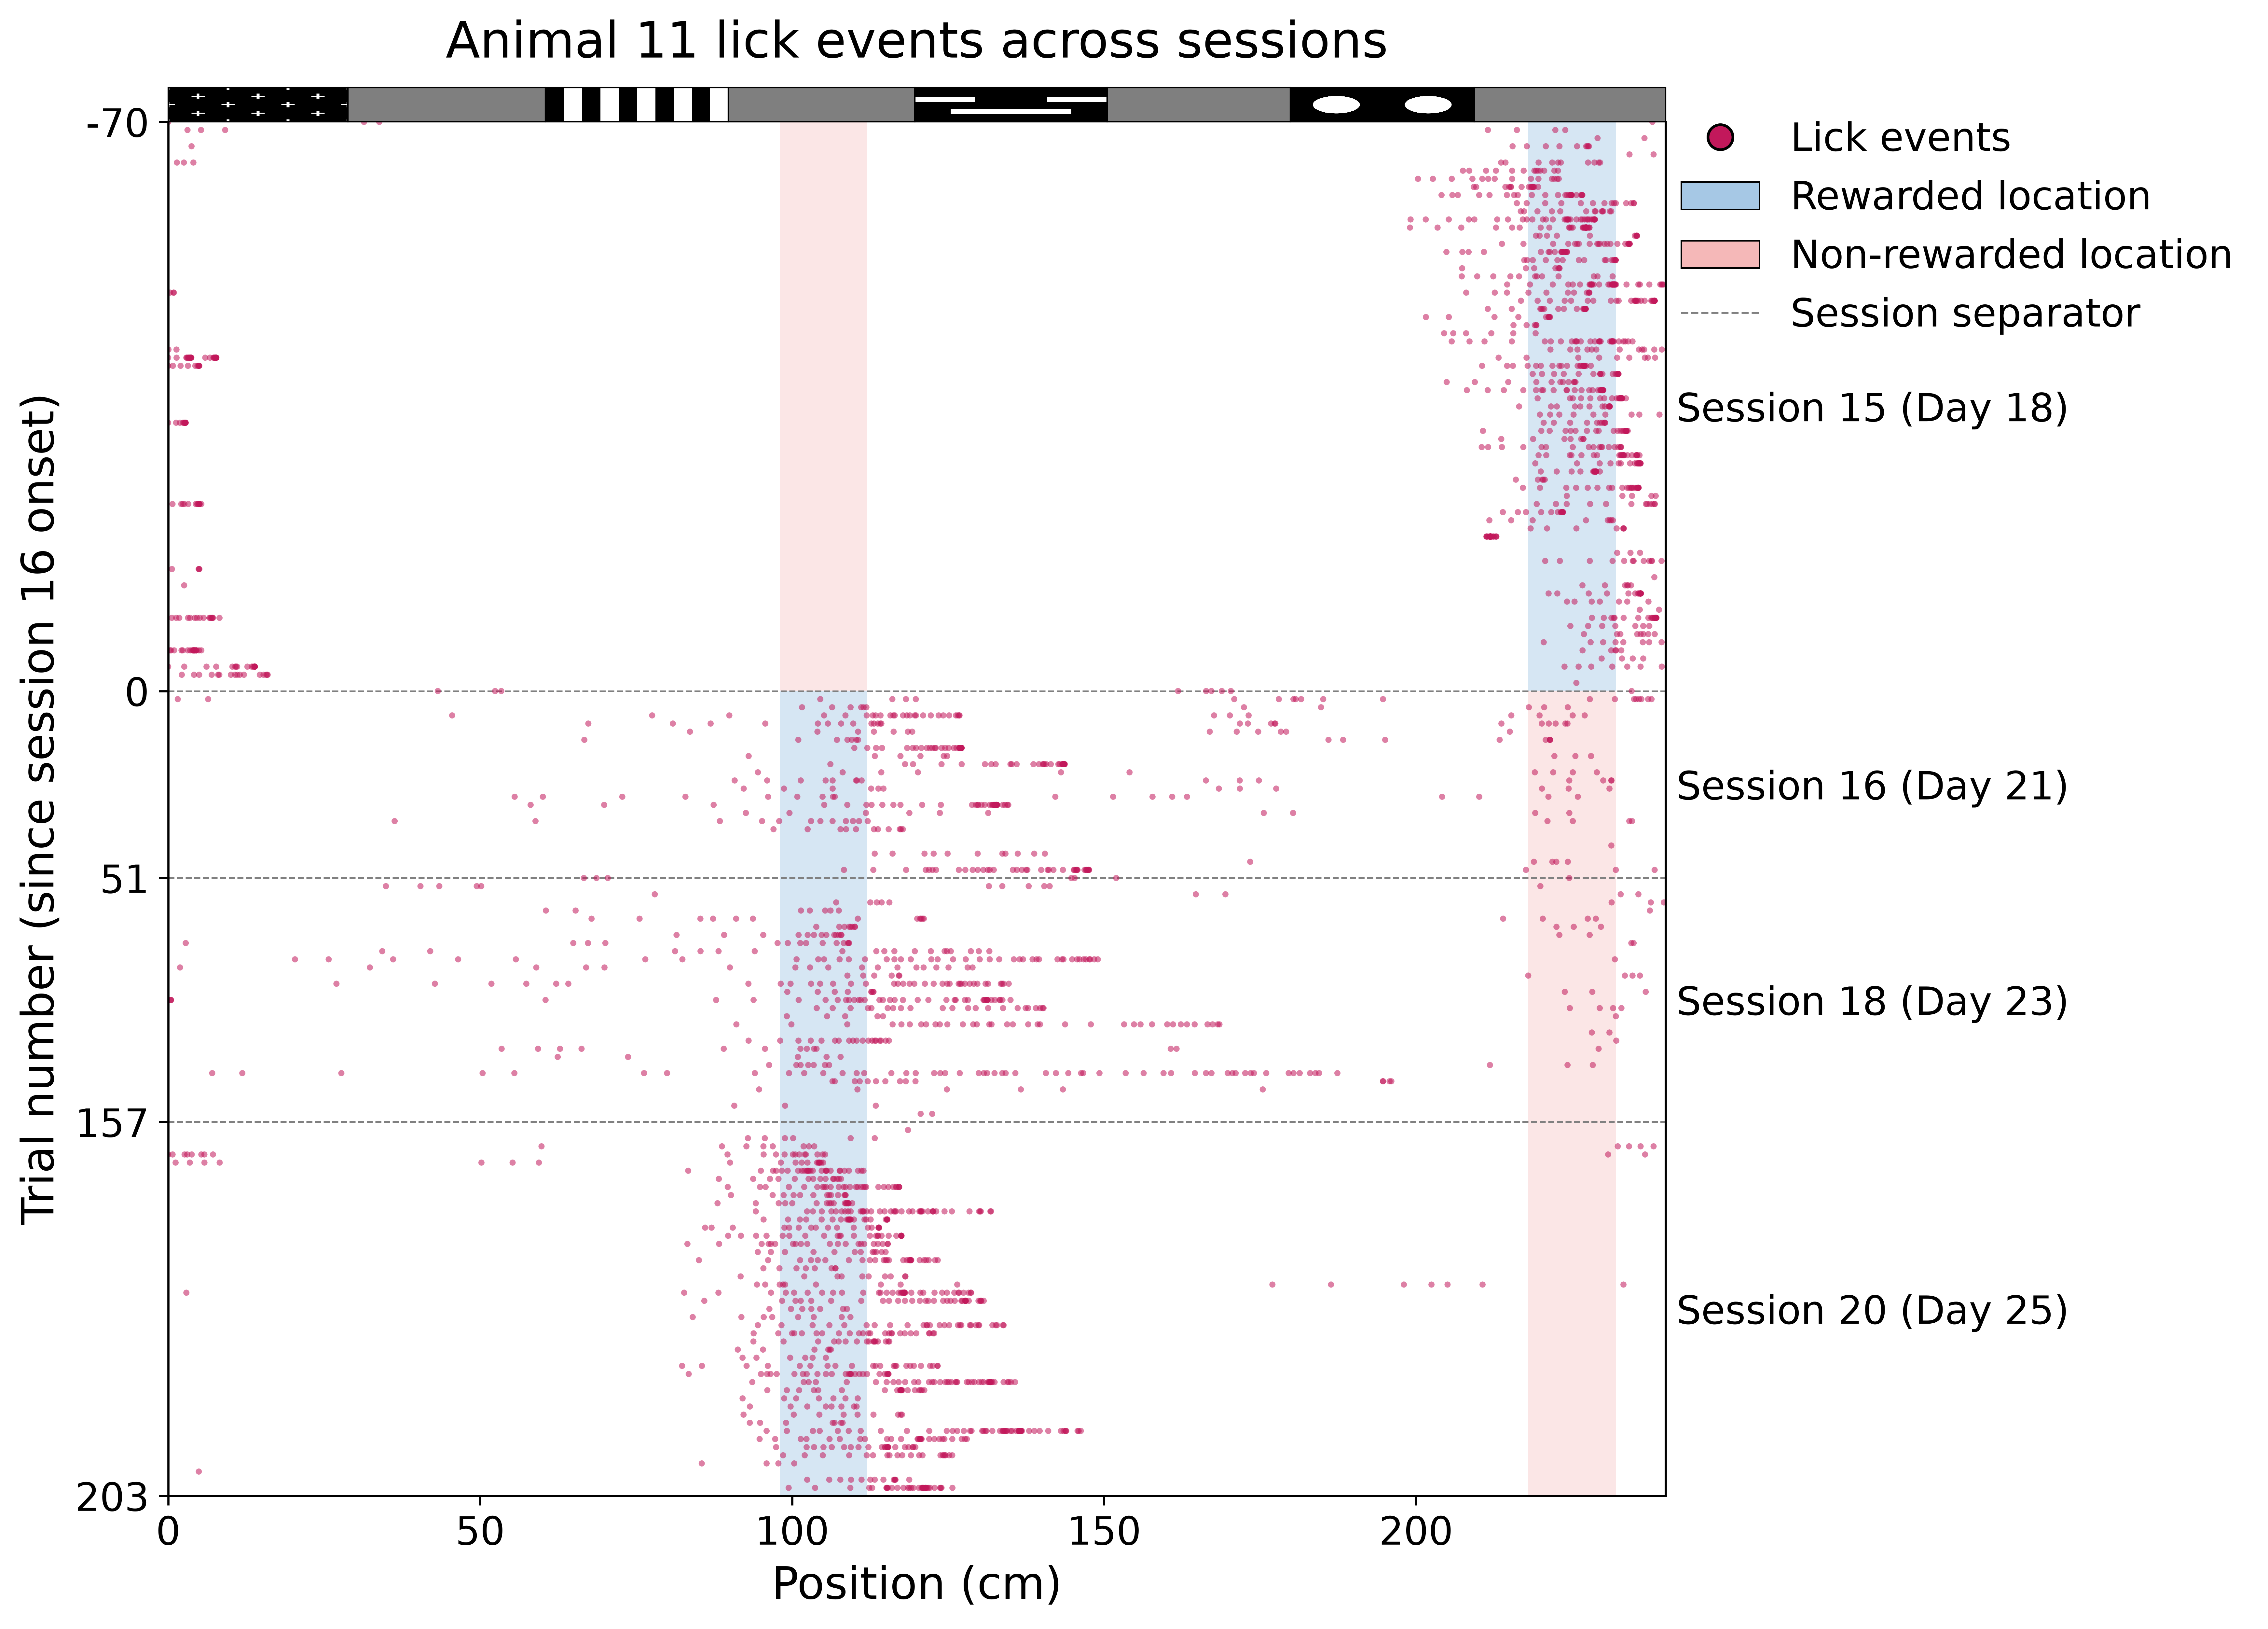

In [28]:
# Cell-local knobs for the lick scatter:
# - ``LICK_MAX_TRIALS_PER_SESSION`` caps each session's trial count before rendering so dense
#   sessions stay legible (None disables the cap, 0 drops every trial).
# - ``LICK_TRIAL_ORIGIN_SESSION`` is the 1-indexed session whose first trial becomes
#   trial-axis index 0; trials of earlier retained sessions render with negative numbers,
#   trials of later retained sessions render with non-negative numbers.
# - ``RAW_DATA_ROOT`` is the per-project raw data tree where each session's
#   ``raw_data/experiment_configuration.yaml`` lives; the loader globs it for any animal's
#   config since the experiment configuration is shared across animals in the project.
# - ``UNITY_TEXTURES_DIR`` is the Unity project's cue-texture folder.
LICK_MAX_TRIALS_PER_SESSION: int | None = 70
LICK_TRIAL_ORIGIN_SESSION: int | None = 16
RAW_DATA_ROOT: Path = Path("/home/data/Data/MaalstroomicFlow")
UNITY_TEXTURES_DIR: Path = Path(
    "/home/cyberaxolotl/Desktop/GitHubRepos/sollertia-unity-tasks/Assets/InfiniteCorridorTask/Textures"
)
cue_textures = load_cue_textures(
    experiment_config_path=next(RAW_DATA_ROOT.glob("*/*/raw_data/experiment_configuration.yaml")),
    textures_dir=UNITY_TEXTURES_DIR,
)

plot_lick_scatter(
    context=lick_context,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    cue_textures=cue_textures,
    max_trials_per_session=LICK_MAX_TRIALS_PER_SESSION,
    trial_origin_session=LICK_TRIAL_ORIGIN_SESSION,
    figure_preset=FIGURE_PRESET,
    figure_dpi=600,
)
plt.show()

## 5. Tuning outputs

Per-session tuning plots restricted to `DISPLAY_SESSIONS` (sections 5.1 and 5.2). Section 5.3 averages over the `BEFORE_SHIFT_SESSIONS` and `AFTER_SHIFT_SESSIONS` groups instead.

### 5.1 Per-day-sorted rate maps — all cells

Per-session view across the animal's selected session range: every registered cell renders as a row, sorted independently by *that session's* peak position. Rate maps are raw ΔF/F₀ on a shared percentile-clipped color scale so amplitudes are directly comparable between panels. Use this view for a global sense of the population's tuning band; pair with section 5.3 for the active-cell-only band.

In [ ]:
plot_sorted_heatmap(
    sessions=sessions,
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=300,
    cmap="cmo.thermal",
    figure_preset=FIGURE_PRESET,
)
plt.show()

### 5.2 Per-day-sorted rate maps — classified cells

Per-session view restricted to one classifier-active subset. ``classifier="place"`` always selects ``IS_STRICT_PLACE`` (place-field morphology + lap coverage + split-half stability + per-cell peak shuffle); ``classifier="reward"`` selects ``IS_REWARD_CELL``. Each cell's row is divided by its own peak so the colorbar is fixed at ``[0, 1]`` regardless of absolute ΔF/F₀ amplitude. Cell counts vary across panels (the active set differs by day), so the y-axis is tickless and the per-panel ``Session X (Day Y, n=N)`` title carries the count.

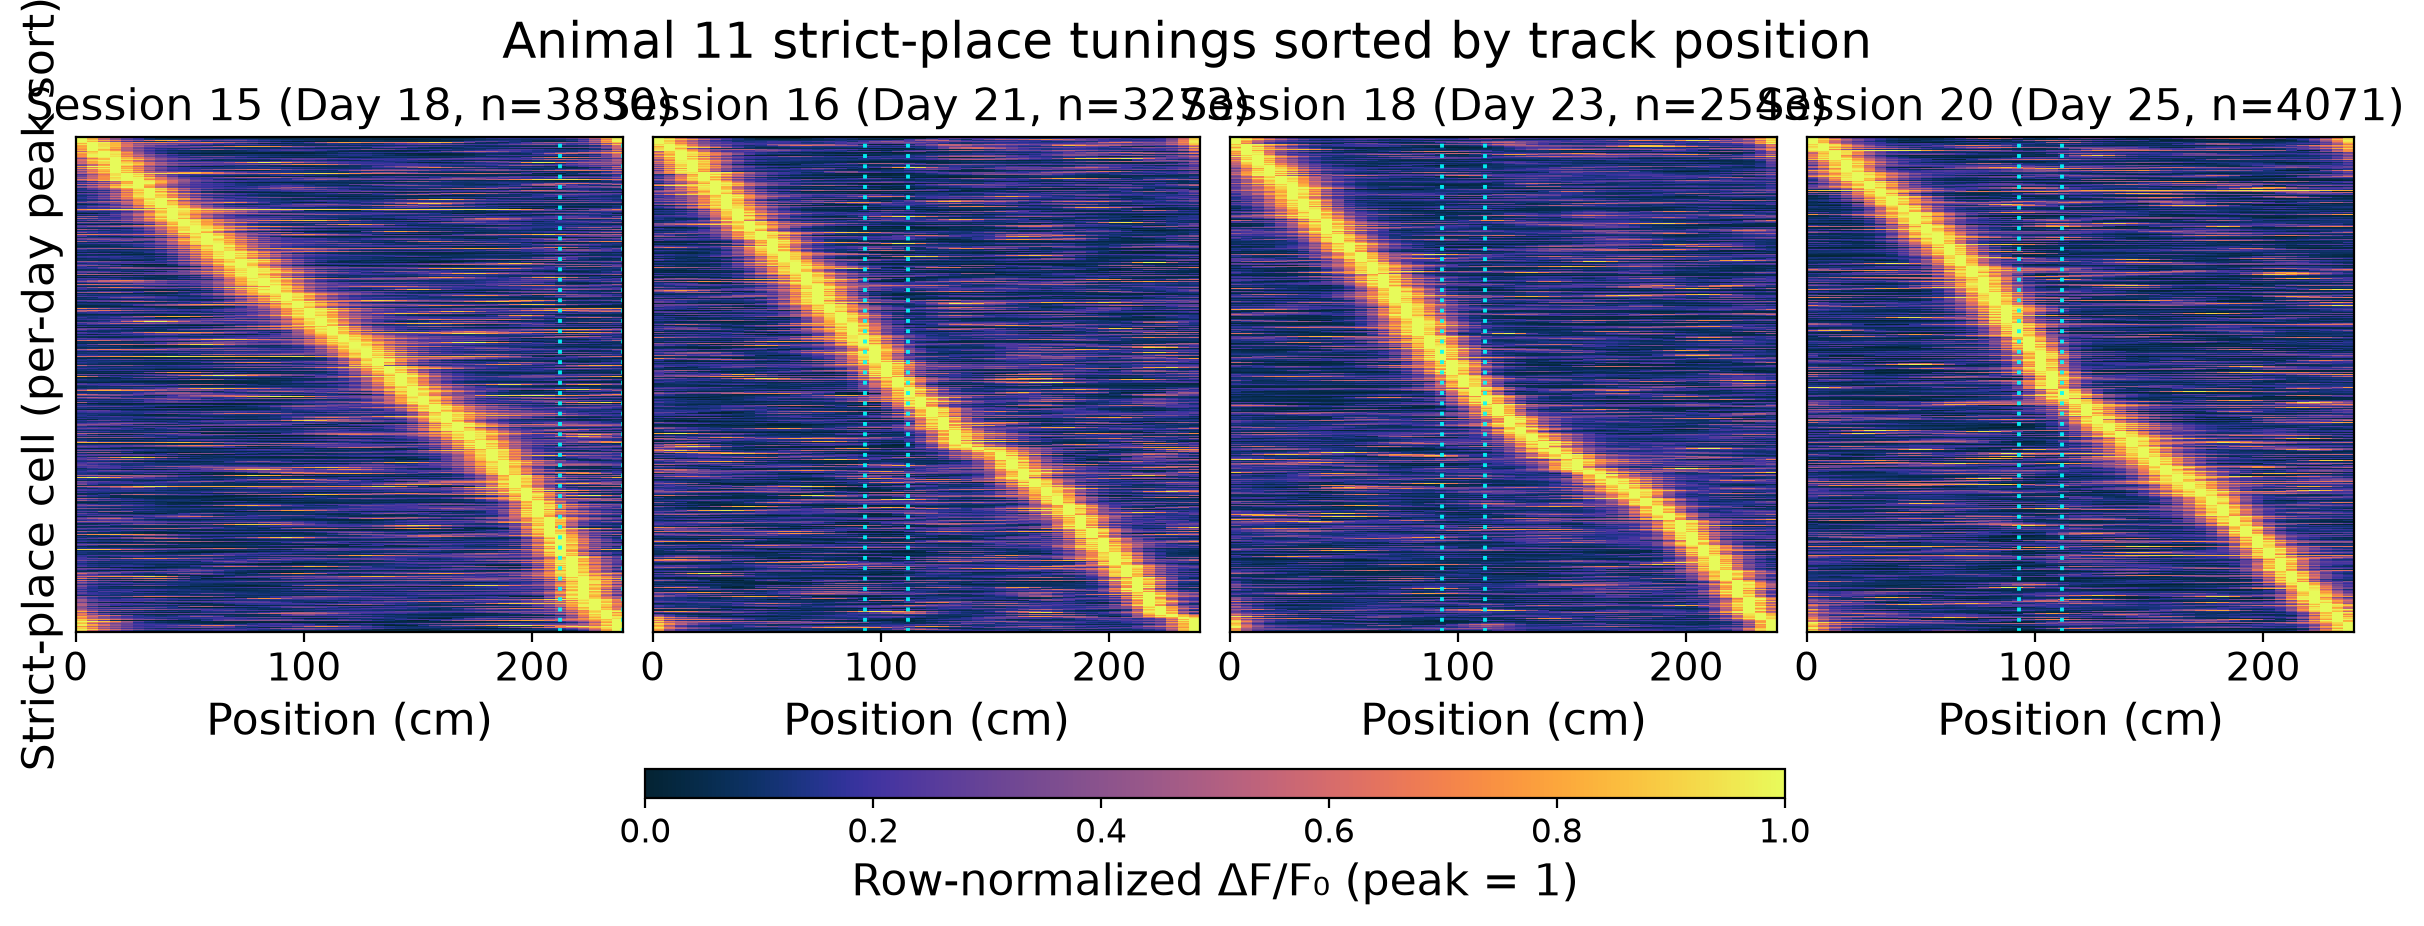

In [30]:
plot_classified_heatmap(
    sessions=sessions,
    classifier="place",  # "place" → IS_STRICT_PLACE; switch to "reward" for IS_REWARD_CELL
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=200,
    cmap="cmo.thermal",
    figure_preset=FIGURE_PRESET,
)
plt.show()

### 5.3 Place-cell peak-location distribution before vs after reward shift

Replicates the layout of Sun et al. 2022 (Nature) Fig. 1h: the entire track is partitioned into cue-aligned bins (one cue wide, no two adjacent cues sharing a bin), the fraction of strict-place cells whose rate-map peak falls in each bin is averaged across the supplied 'before' and 'after' session groups, and the two averages render as line traces with SEM error bars. Vertical dashed lines mark the trigger-zone center from each group's first session so a reward shift between groups reads off the figure directly.

Uses `BEFORE_SHIFT_SESSIONS` and `AFTER_SHIFT_SESSIONS` from the selection cell to pick which sessions to average.

In [ ]:
plot_place_cell_peak_distribution_around_shift(
    sessions=sessions,
    before_sessions=BEFORE_SHIFT_SESSIONS,
    after_sessions=AFTER_SHIFT_SESSIONS,
    trial_type=trial_type,
    animal_id=ANIMAL,
    figure_dpi=150,
    figure_preset=FIGURE_PRESET,
)
plt.show()

### 5.5 Cohort peak-location distribution: two sessions compared

Two-session cohort comparison. `COHORT_SESSION_A` and `COHORT_SESSION_B` pick two specific 1-indexed session numbers (resolved against each animal's chronological list). Each animal contributes one per-bin fraction row per session, and the rendered traces are the cohort mean ± SEM across animals. The function enforces that both sessions report the same trigger-zone center for every contributing animal — comparing across reward-zone shifts belongs in section 5.3 instead.

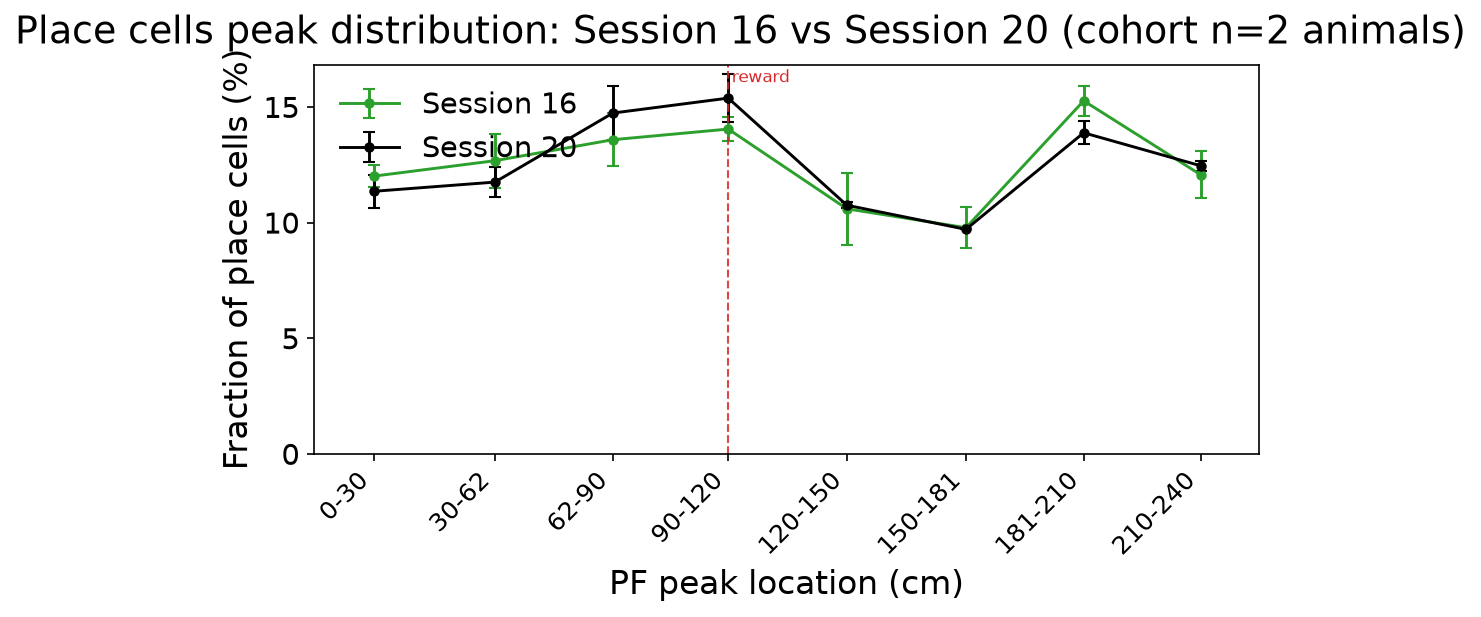

In [20]:
# Cell-local knobs:
# - ``ANIMALS`` lists the animal ids whose paired sessions are averaged together for the
#   cohort traces. Each entry contributes its chronologically sorted DatasetSession tuple
#   resolved against the same dataset.
# - ``COHORT_SESSION_A`` / ``COHORT_SESSION_B`` are two specific 1-indexed session numbers
#   (resolved against each animal's chronological list). Both must come from the same
#   reward-zone era — the function raises ``ValueError`` if it detects a trigger-zone shift
#   between them. For pre-/post-shift comparisons use section 5.3 instead.
ANIMALS: tuple[str, ...] = ("11", "15")
COHORT_SESSION_A: int = 16
COHORT_SESSION_B: int = 20

sessions_by_animal: dict[str, tuple] = {}
for animal_id in ANIMALS:
    animal_sessions = tuple(
        sorted(
            dataset.get_sessions_for_animal(animal=animal_id),
            key=lambda dataset_session: dataset_session.session,
        )
    )
    if animal_sessions:
        sessions_by_animal[animal_id] = animal_sessions

plot_place_cell_peak_distribution_across_animals(
    sessions_by_animal=sessions_by_animal,
    session_a=COHORT_SESSION_A,
    session_b=COHORT_SESSION_B,
    trial_type=trial_type,
    figure_dpi=150,
    figure_preset=FIGURE_PRESET,
)
plt.show()

### 5.6 Post-shift reward-zone cells in last pre-shift session

Identifies strict-place cells whose rate-map peak falls in the post-shift reward cue (the gray cue containing the trigger-zone center) plus the cue immediately upstream — a two-cue window that covers reward delivery and the anticipatory approach — across every session in `AFTER_SHIFT_SESSIONS`, then renders that cell set's rate maps in the last session of `BEFORE_SHIFT_SESSIONS` (the last pre-shift day) as a row-normalized heatmap sorted by reference-session peak. The translucent cyan band marks the post-shift cue window so the eye can read directly whether the back-projected peaks already cluster there or sit elsewhere on the track.

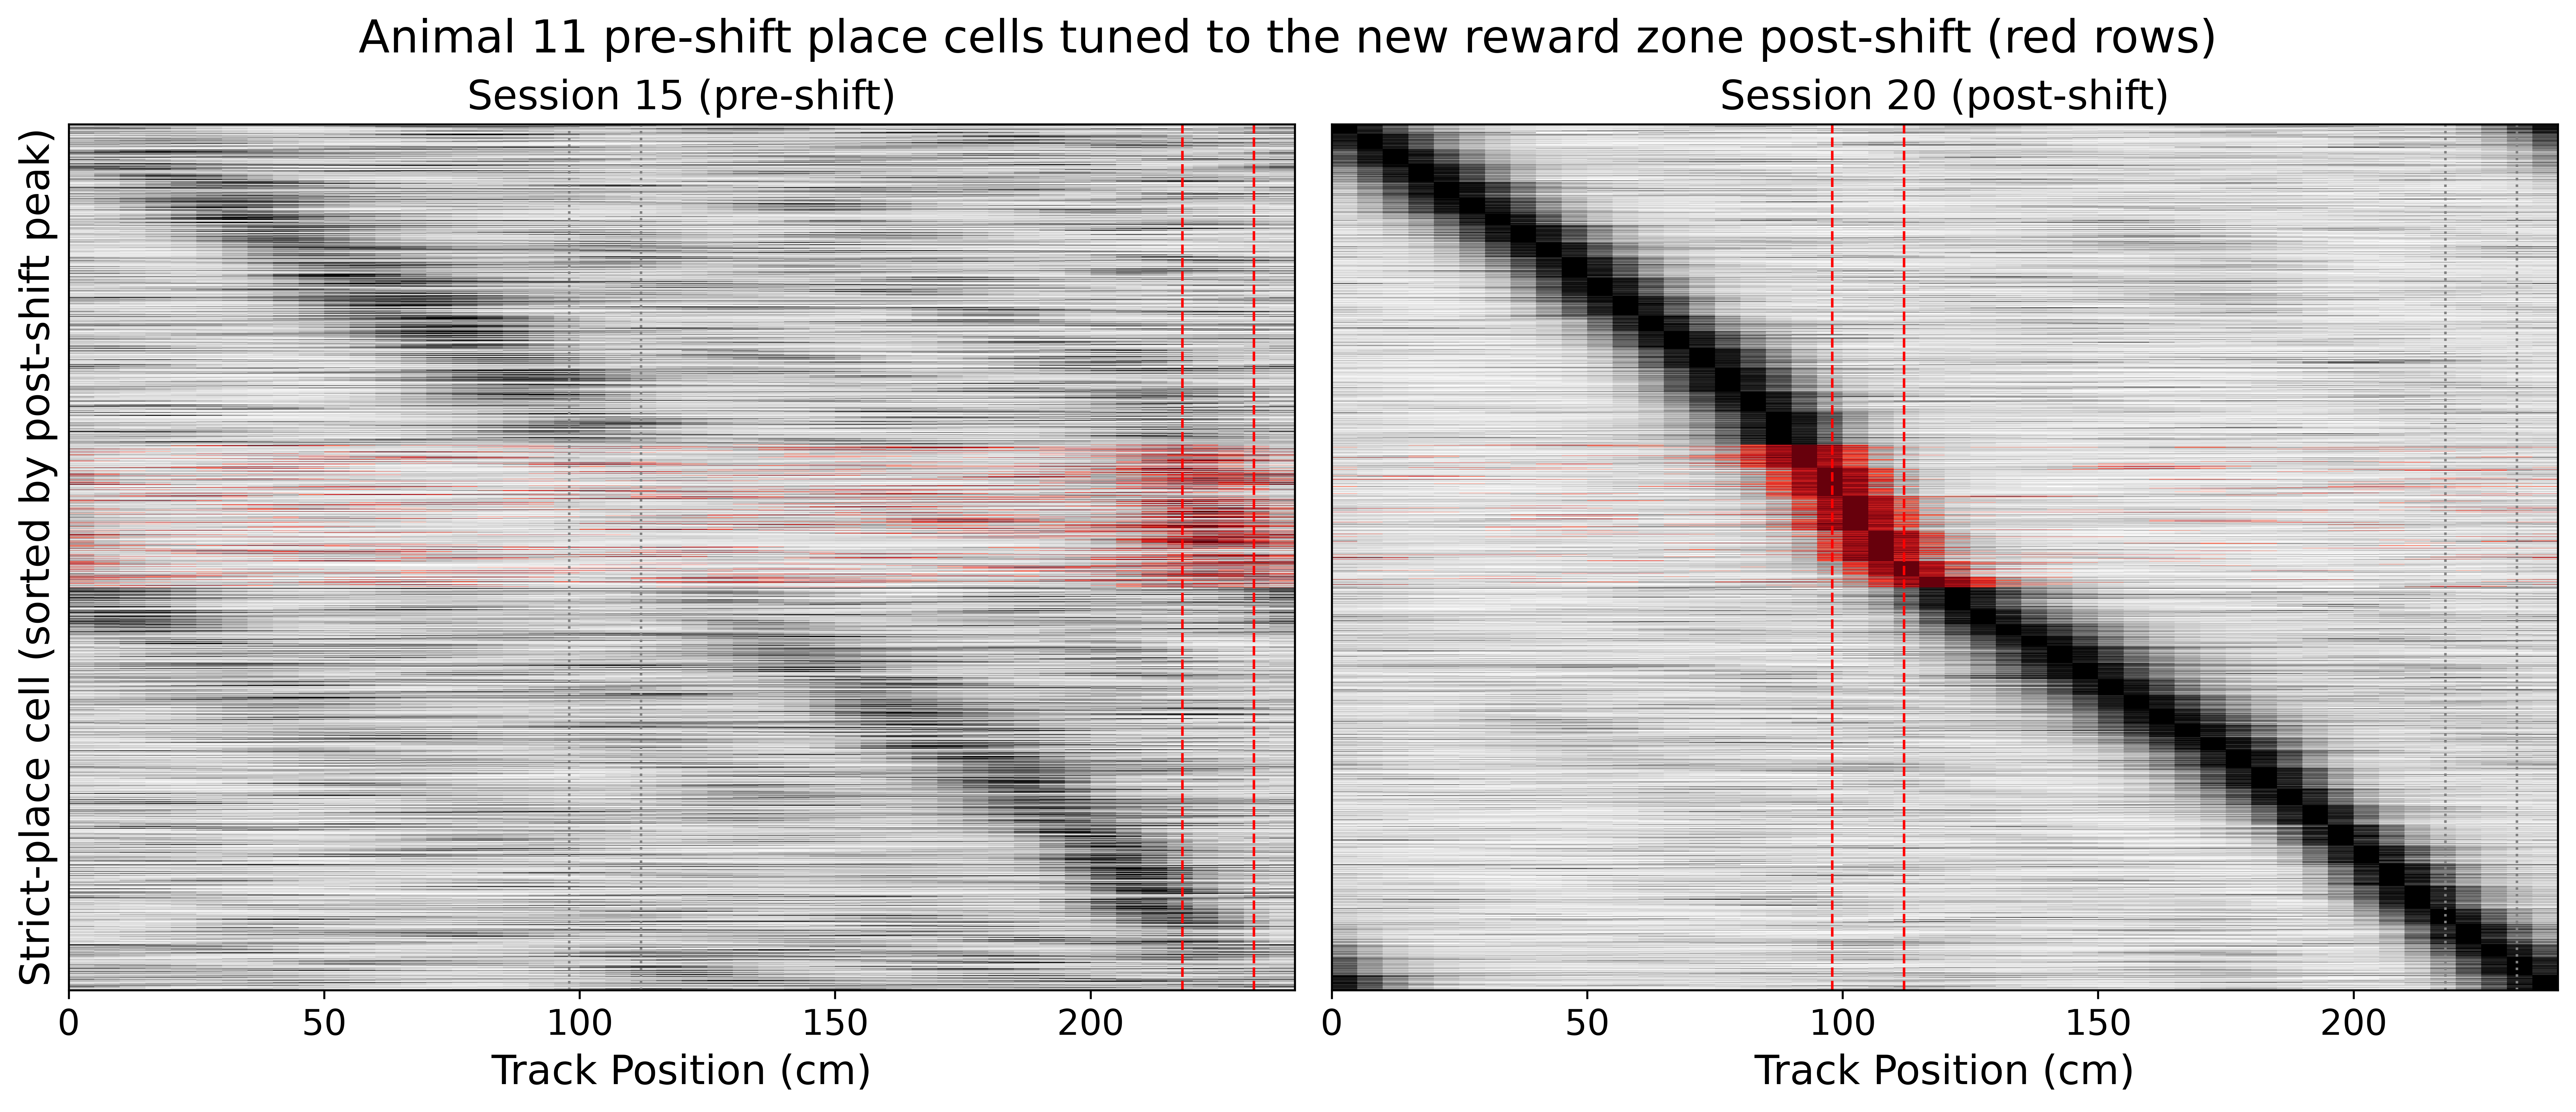

In [36]:
plot_post_shift_reward_zone_cells_in_session(
    sessions=sessions,
    pre_shift_session=BEFORE_SHIFT_SESSIONS[-1],
    post_shift_session=AFTER_SHIFT_SESSIONS[-1],
    trial_type=trial_type,
    animal_id=ANIMAL,
    figure_dpi=600,
    figure_preset=FIGURE_PRESET,
)
plt.show()

### 5.7 Pre-shift reward-zone cells in post-shift session

Inverse of section 5.6. Identifies strict-place cells whose pre-shift peak falls inside the OLD reward cue (the cue containing the pre-shift trigger-zone center) and shows where those same cells ended up post-shift. Use this to ask 'where did the cells that used to anchor on the old reward zone migrate to after the shift?'

In [ ]:
plot_pre_shift_reward_zone_cells_in_session(
    sessions=sessions,
    pre_shift_session=BEFORE_SHIFT_SESSIONS[-1],
    post_shift_session=AFTER_SHIFT_SESSIONS[-1],
    trial_type=trial_type,
    animal_id=ANIMAL,
    figure_dpi=150,
    figure_preset=FIGURE_PRESET,
)
plt.show()